# Procesamiento de Señales e Imágenes
**USACH - 2025-2**

**Profesor de cátedra:** Cristóbal Loyola

**Ayudante:** Clemente Aguilar

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
import math

from skimage import filters, util, feature
from scipy import ndimage as ndi

In [ ]:
%ls

# Cargar imagen propia con 3 canales
mi_imagen = cv2.imread('tiger.jpeg')
#mi_imagen = cv2.cvtColor(mi_imagen, cv2.COLOR_BGR2RGB)

sample_data/  tiger.jpeg


In [ ]:
def show_img(img):
    plt.imshow(img, cmap='gray')
    plt.show()

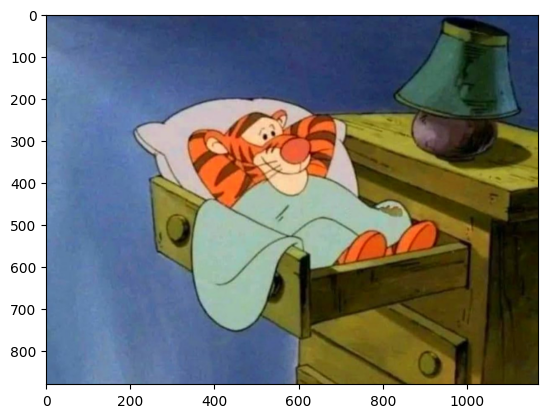

(879, 1170, 3)


In [ ]:
show_img(mi_imagen)
print(mi_imagen.shape)

# RGB a Escala de grises

In [ ]:
# Implementación manual solo para fines didácticos.
# Cómputo costoso en imágenes grandes
def rgb_2_gray_manual(imagen_rgb):
    if imagen_rgb.ndim != 3:
        return -1

    filas, columnas, _ = imagen_rgb.shape
    imagen_gray = np.zeros((filas, columnas), dtype=np.uint8)

    for i in range(filas):
        for j in range(columnas):
            R = imagen_rgb[i, j, 0]
            G = imagen_rgb[i, j, 1]
            B = imagen_rgb[i, j, 2]

            # Fórmula de Charles Poynton https://poynton.ca/PDFs/ColorFAQ.pdf
            gris = 0.2125 * R + 0.7154 * G + 0.0721 * B

            imagen_gray[i, j] = int(gris)

    return imagen_gray

# Mejor usar conversión de OpenCV
def rgb_2_gray(imagen_bgr):
    if imagen_bgr.ndim != 3:
        return -1
    imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
    return imagen_gris



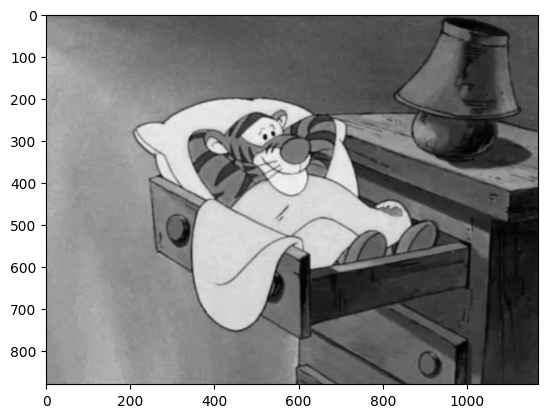

(879, 1170)


In [ ]:
#mi_imagen_gris = rgb_2_gray_manual(mi_imagen)
mi_imagen_gris = rgb_2_gray(mi_imagen)
show_img(mi_imagen_gris)
print(mi_imagen_gris.shape)

# Histograma

In [ ]:
def histograma(imagen_gris):
    if imagen_gris.ndim != 2:
        return -1

    bins = np.zeros(256, dtype=int)

    filas, columnas = imagen_gris.shape

    for i in range(filas):
        for j in range(columnas):
            intensidad = imagen_gris[i, j]
            bins[intensidad] += 1

    # Graficar
    plt.figure()
    plt.bar(range(256), bins, width=1)
    plt.xlabel("Intensidad [0, 255]")
    plt.ylabel("Frecuencia (pixeles)")
    plt.title("Histograma")
    plt.xlim([-5, 260]) #padding de 5 en el eje x para visualización
    plt.show()

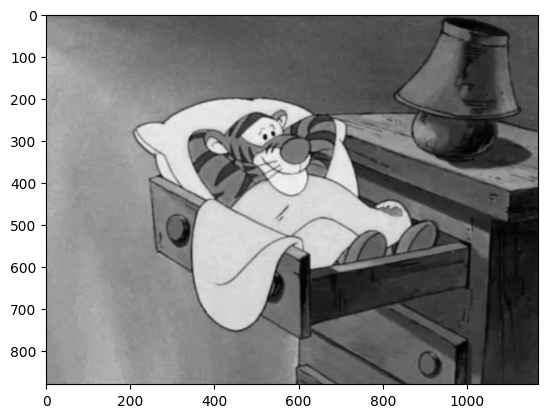

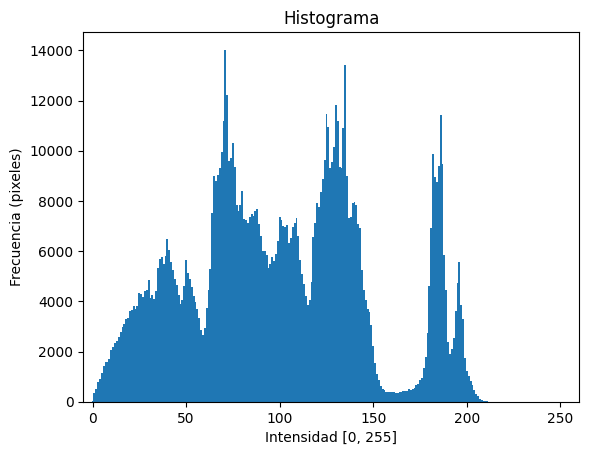

In [ ]:
show_img(mi_imagen_gris)
histograma(mi_imagen_gris)

# Binarización
## Binarización según umbral

In [ ]:
def binarizacion(imagen_gris, umbral):
    filas, columnas = imagen_gris.shape

    imagen_bin = np.zeros((filas, columnas), dtype=np.uint8)

    imagen_bin[imagen_gris <= umbral] = 0
    imagen_bin[imagen_gris > umbral] = 255

    return imagen_bin

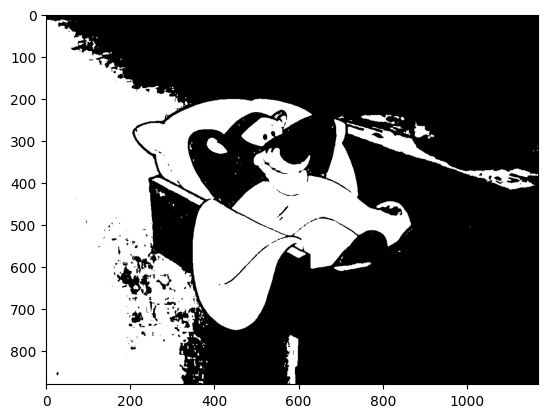

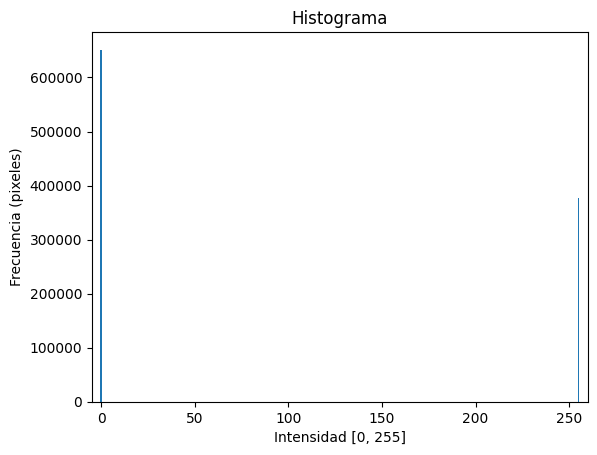

In [ ]:
imagen_bin = binarizacion(mi_imagen_gris, 120)
show_img(imagen_bin)
histograma(imagen_bin)

## Binarización Isodata

In [ ]:
def bin_isodata(imagen_gris, tetha_inicial, delta_min=1):
    tetha_i = float(tetha_inicial)
    delta = float("inf") #diferencia infinita para la iteración 1

    while delta > delta_min:

        fondo = imagen_gris[imagen_gris <= tetha_i]
        objeto = imagen_gris[imagen_gris > tetha_i]

        # Esto es para evitar dividir por 0 cuando el umbral es malo
        if len(fondo) == 0 or len(objeto) == 0:
            break

        # Promedios
        p_fondo = np.mean(fondo)
        p_objeto = np.mean(objeto)

        tetha_next = (p_fondo + p_objeto) / 2.0

        delta = abs(tetha_next - tetha_i)
        tetha_i = tetha_next

    imagen_bin = binarizacion(imagen_gris, tetha_i)

    return imagen_bin, tetha_i

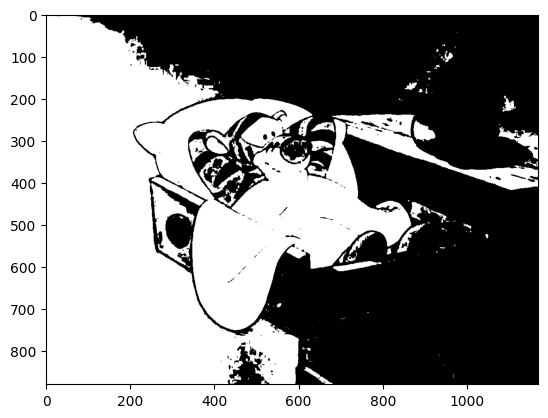

Umbral isodata: 103


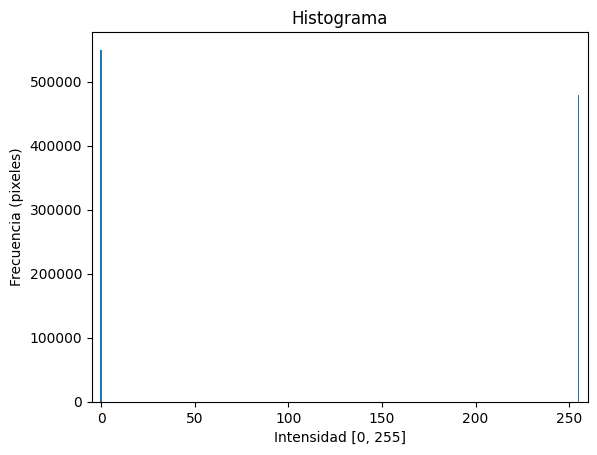

In [ ]:
imagen_bin_isodata, umbral_isodata = bin_isodata(mi_imagen_gris, 200)
show_img(imagen_bin_isodata)
print("Umbral isodata:", math.trunc(umbral_isodata))
histograma(imagen_bin_isodata)

## Binarización Otsu

In [ ]:
def bin_otsu(imagen_gris):

    filas, columnas = imagen_gris.shape
    total_pixeles = filas * columnas

    # Cálculo manual del histograma
    hist = np.zeros(256, dtype=np.int64)
    for i in range(filas):
        for j in range(columnas):
            intensidad = imagen_gris[i, j]
            hist[intensidad] += 1

    # Normalizar probabilidades
    prob = hist / total_pixeles

    # Obtener media global
    media_global = 0.0
    for i in range(256):
        media_global += i * prob[i]

    # Evaluación del criterio de Otsu (maximizar varianza)
    varianza_max = -1.0
    tetha_opt = 0

    peso_fondo = 0.0
    media_fondo = 0.0

    for t in range(256):
        peso_fondo += prob[t]
        if peso_fondo == 0:
            continue

        peso_objeto = 1.0 - peso_fondo
        if peso_objeto == 0:
            break

        media_fondo += t * prob[t]
        media_objeto = (media_global - media_fondo) / peso_objeto

        media_fondo_norm = media_fondo / peso_fondo

        # Varianza entre clases
        varianza_inter = (
            peso_fondo * peso_objeto *
            (media_fondo_norm - media_objeto) ** 2
        )

        if varianza_inter > varianza_max:
            varianza_max = varianza_inter
            tetha_opt = t

    # Binarización final
    imagen_bin = binarizacion(imagen_gris, tetha_opt)

    return imagen_bin, tetha_opt


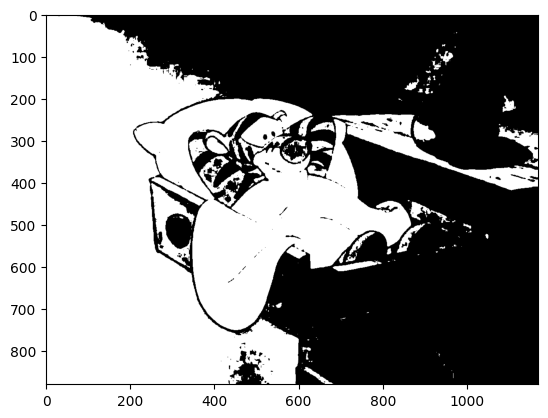

Umbral Otsu: 102


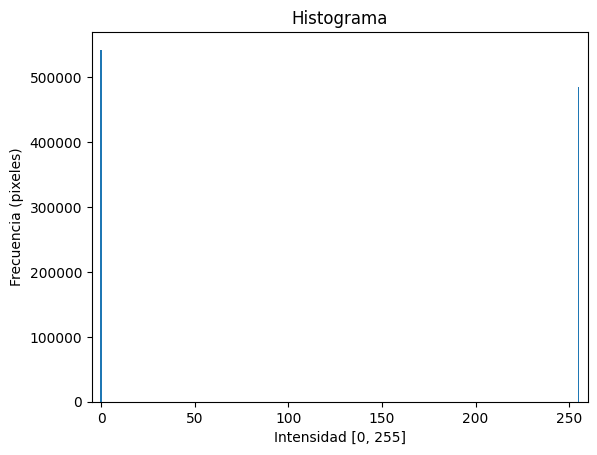

In [ ]:
imagen_bin_otsu, umbral_otsu = bin_otsu(mi_imagen_gris)
show_img(imagen_bin_otsu)
print("Umbral Otsu:", math.trunc(umbral_otsu))
histograma(imagen_bin_otsu)

## Binarización adaptativa

In [ ]:
def bin_adaptativa(imagen_gris, block_size):
    # Hago uso de la implementación de Scikit-imagenes del módulo filters
    adaptive_thr = filters.threshold_local(imagen_gris, block_size=block_size, offset=10)
    bin_img = imagen_gris > adaptive_thr
    return bin_img


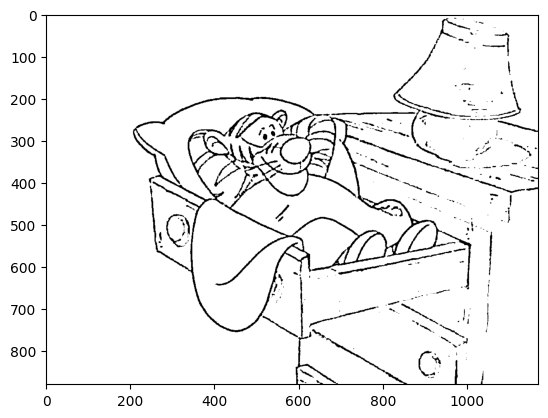

In [ ]:
imagen_bin_adaptativa = bin_adaptativa(mi_imagen_gris, 21)
show_img(imagen_bin_adaptativa)

# Ruido
## Sal y Pimienta

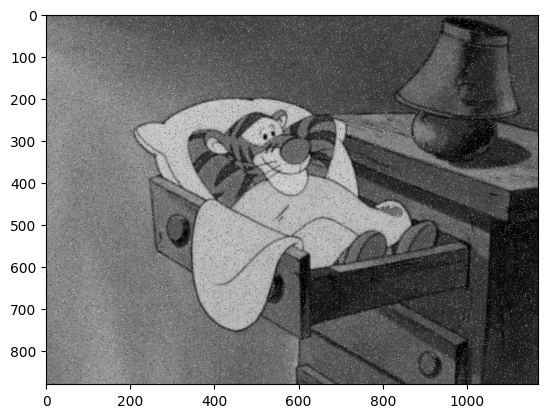

In [ ]:
imagen_syp = util.random_noise(mi_imagen_gris, mode='s&p', amount=0.05)
show_img(imagen_syp)

## Impulso o Speckle

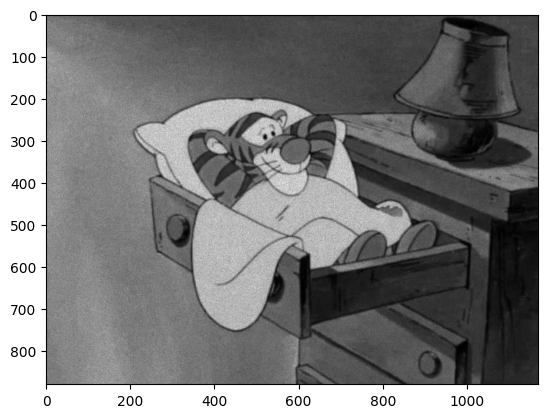

In [ ]:
imagen_speckle = util.random_noise(mi_imagen_gris, mode='speckle')

show_img(imagen_speckle)

## Gaussiano

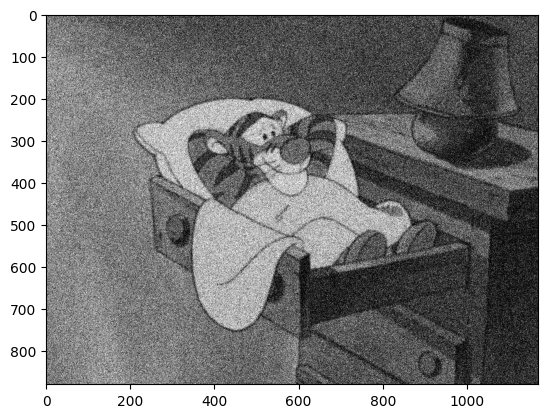

In [ ]:
imagen_gauss_noise = util.random_noise(mi_imagen_gris, mode='gaussian', var=0.05)

show_img(imagen_gauss_noise)

# Filtros
## Convolución

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1N5rzzRDku_m0jg7yExqh2AWm4Nz8-ESj" width="600"/>
</center>
</div>

In [ ]:
# Definición de un filtro, kernel o máscara de convolución
kernel = np.array([[1, 0, -1],
                   [1, 0, -1],
                   [1, 0, -1]])

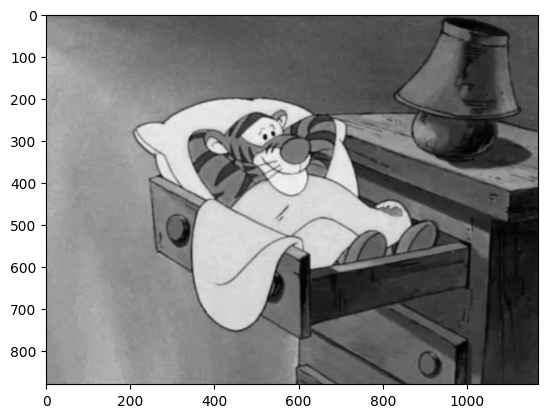

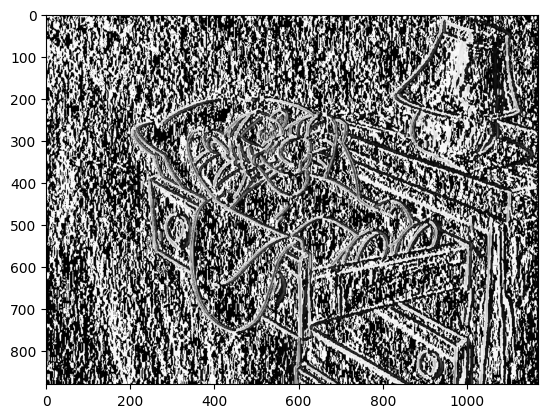

In [ ]:
imagen_convolucionada = ndi.convolve(mi_imagen_gris, kernel)

show_img(mi_imagen_gris)
show_img(imagen_convolucionada)

## Box Filter o Filtro Promedio

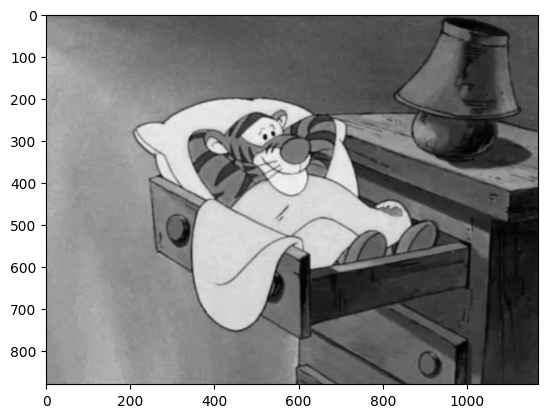

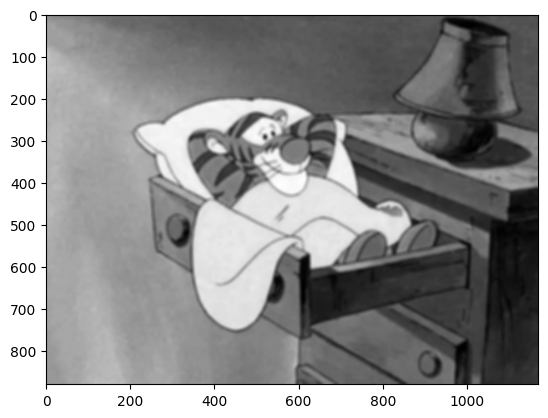

In [ ]:
dim_kernel = 9
kernel_box = np.ones((dim_kernel, dim_kernel)) / (dim_kernel**2)

imagen_box = ndi.convolve(mi_imagen_gris, kernel_box)

show_img(mi_imagen_gris)
show_img(imagen_box)

## Filtro Mediana

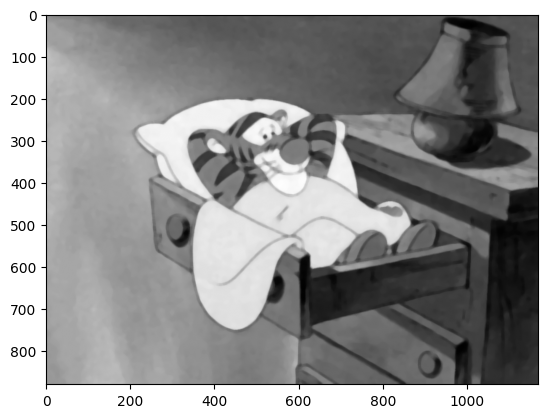

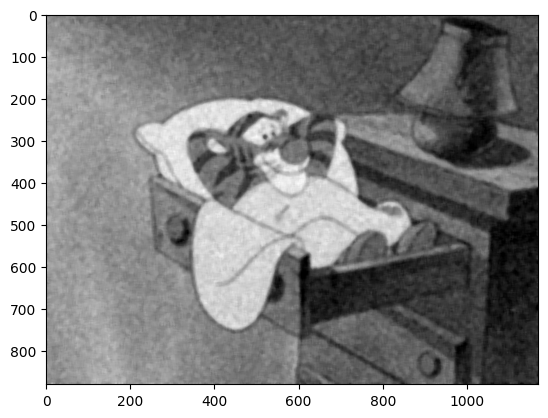

In [ ]:
imagen_syp_median = filters.median(imagen_syp, footprint=np.ones((11, 11)))
imagen_gauss_median = filters.median(imagen_gauss_noise, footprint=np.ones((11, 11)))

show_img(imagen_syp_median)
show_img(imagen_gauss_median)

## Filtro Gaussiano

<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1vWVeICpIKaP1mYGmot06wrnGRjJZ63sG" width="600"/>
</center>
</div>

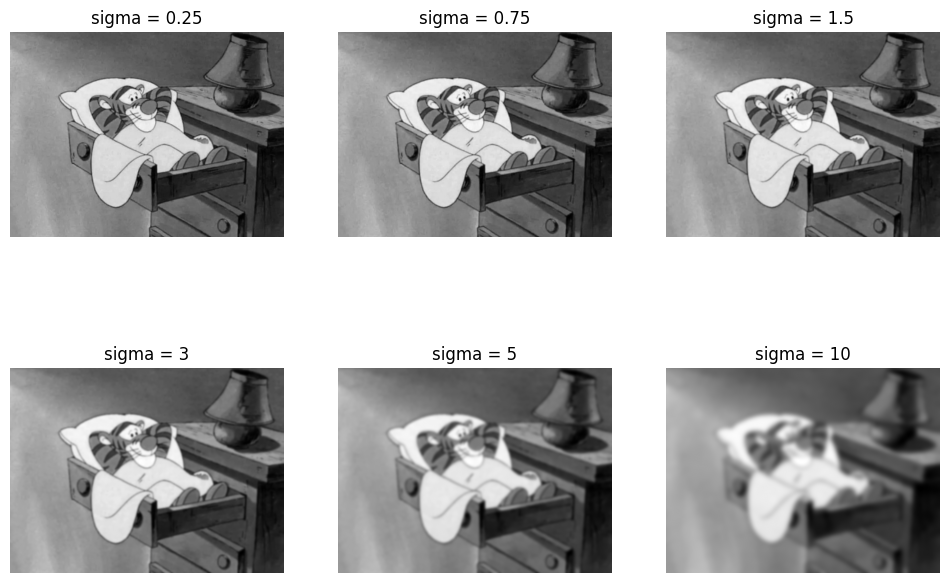

In [ ]:
sigma_range = [0.25, 0.75, 1.5, 3, 5, 10]

plt.figure(figsize=(12, 8))
for i in range(len(sigma_range)):
    image_gauss = filters.gaussian(mi_imagen_gris, sigma=sigma_range[i])
    plt.subplot(2, 3, i+1)
    plt.imshow(image_gauss, cmap='gray')
    plt.title(f'sigma = {sigma_range[i]}')
    plt.axis('off')

# Realce

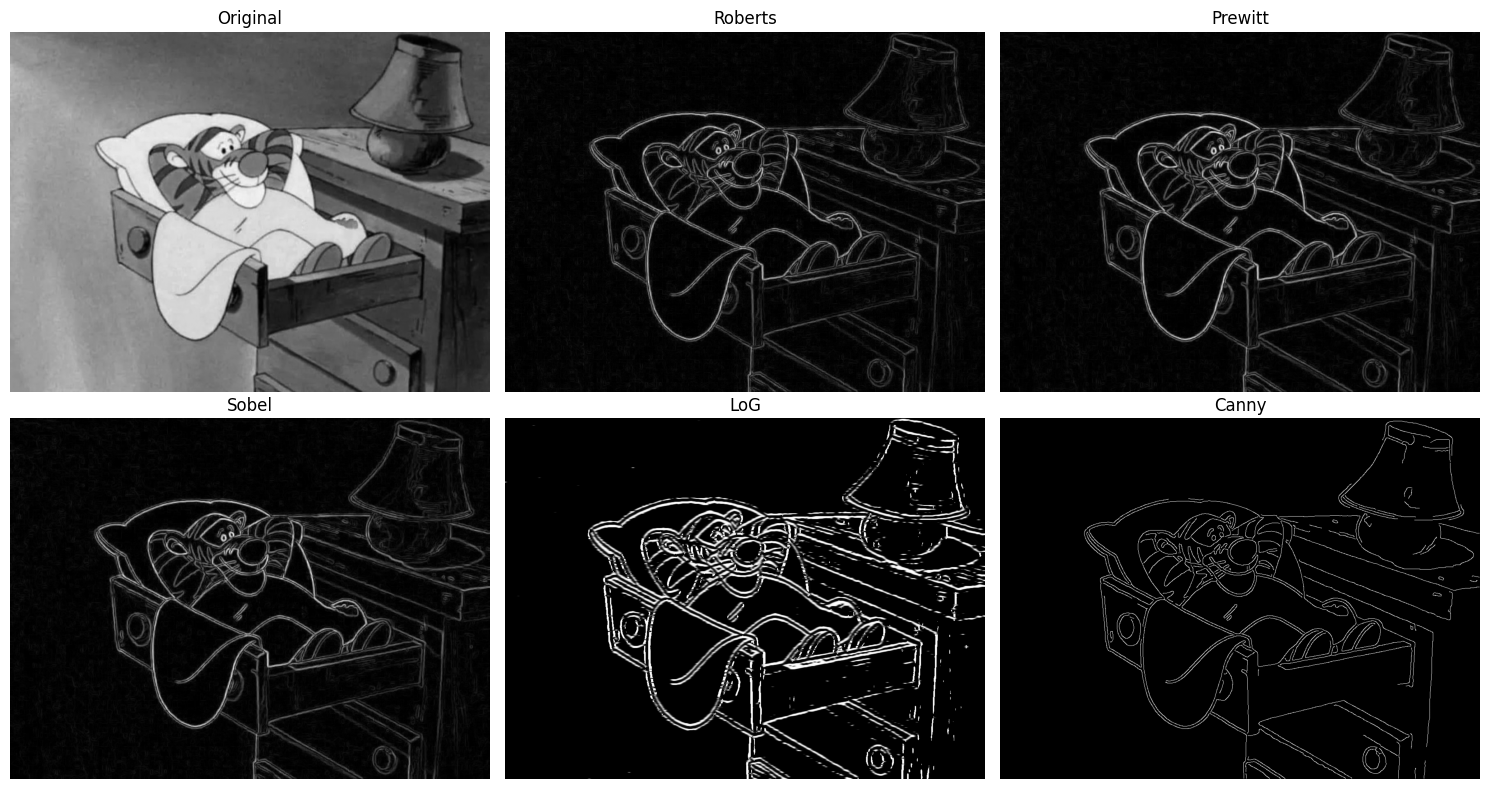

In [ ]:
# Aplicar filtros
edges_roberts = filters.roberts(mi_imagen_gris)
edges_prewitt = filters.prewitt(mi_imagen_gris)
edges_sobel = filters.sobel(mi_imagen_gris)
edges_log = ndi.gaussian_laplace(mi_imagen_gris, sigma=2)
edges_canny = feature.canny(mi_imagen_gris, sigma=2)

# Mostrar resultados
plt.figure(figsize=(15, 8))

titles = ['Original', 'Roberts', 'Prewitt', 'Sobel', 'LoG', 'Canny']
imagenes = [mi_imagen_gris, edges_roberts, edges_prewitt, edges_sobel, edges_log, edges_canny]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(imagenes[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()